In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models, datasets
import numpy as np
import cv2
import matplotlib.pyplot as plt

def grad_cam(input_image, model, target_layer, target_class=None, device='cuda'):

    # Set model to eval mode and move to device
    model.eval()
    model.to(device)
    
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),  # Adjust size as needed for your model
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    if not isinstance(input_image, torch.Tensor):
        input_tensor = preprocess(input_image).unsqueeze(0).to(device)
    else:
        input_tensor = input_image.to(device)
    
    # Forward pass to get model output
    output = model(input_tensor)
    
    # If no target class specified, use the highest scoring class
    if target_class is None:
        target_class = torch.argmax(output)
    
    # Zero gradients
    model.zero_grad()
    
    # Backward pass for the target class
    output[0, target_class].backward()
    
    # Get the gradients and activations from the target layer
    gradients = model.get_activations_gradient()
    activations = model.get_activations(input_tensor).detach()
    
    # Pool the gradients across the channels
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
    
    # Weight the activations by the corresponding gradients
    for i in range(activations.shape[1]):
        activations[:, i, :, :] *= pooled_gradients[i]
    
    # Average the weighted activations across channels
    heatmap = torch.mean(activations, dim=1).squeeze()
    
    # Apply ReLU to the heatmap
    heatmap = F.relu(heatmap)
    
    # Normalize the heatmap
    heatmap /= torch.max(heatmap)
    heatmap = heatmap.cpu().numpy()
    
    # Resize heatmap to match input image size
    heatmap = cv2.resize(heatmap, (input_tensor.shape[3], input_tensor.shape[2]))
    
    return heatmap

def visualize_gradcam(image, heatmap, alpha=0.5):
    """
    Visualize the Grad-CAM heatmap on top of the original image.
    
    Args:
        image (numpy.ndarray): Original image (H, W, C)
        heatmap (numpy.ndarray): Grad-CAM heatmap (H, W)
        alpha (float): Transparency for heatmap overlay
    
    Returns:
        numpy.ndarray: Image with heatmap overlay
    """
    # Convert heatmap to RGB
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Convert original image to RGB if grayscale
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    
    # Resize heatmap to match image
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    
    # Superimpose heatmap on image
    superimposed_img = heatmap * alpha + image * (1 - alpha)
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    
    return superimposed_img

In [15]:
class ModelWrapper(nn.Module):
    def __init__(self, model, target_layer):
        super(ModelWrapper, self).__init__()
        self.model = model
        self.target_layer = target_layer
        self.gradient = None
        
        # Register hooks
        target_layer = dict([*self.model.named_modules()])[target_layer]
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activation = output
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradient = grad_output[0]
    
    def get_activations(self, x):
        _ = self.model(x)
        return self.activation
    
    def get_activations_gradient(self):
        return self.gradient
    
    def forward(self, x):
        return self.model(x)

1.0


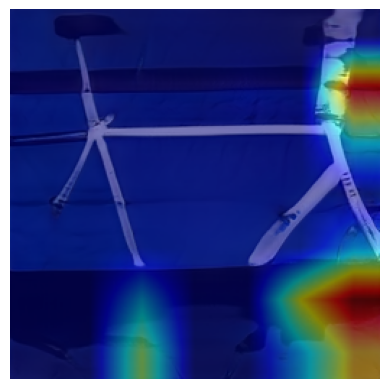

In [ ]:
from torchvision.models import resnet18
from PIL import Image
# Load a pretrained model
def create_model(type):
    if type == 'CNN':
        model = models.resnet50(weights="DEFAULT")
        model.fc = nn.Linear(2048, 1)
        
    elif type == 'ViT':
        model = models.vit_b_16(weights = None)
        model.heads.head = nn.Sequential(
        nn.ReLU(), 
        nn.Linear(768, 1),  # Binary classification
        )
    
    return model
model = create_model('CNN')
model.load_state_dict(torch.load("Enter path to model weight .pth file", weights_only=True))

wrapped_model = ModelWrapper(model, 'layer4.1.conv2')

# Load an image
image = Image.open(r"Enter path to image file")

#Predict whether its AI or not
preprocess = transforms.Compose([
        transforms.Resize((224, 224)),  # Adjust size as needed for your model
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

if not isinstance(image, torch.Tensor):
        input_tensor = preprocess(image).unsqueeze(0)
else:
        input_tensor = image

model.eval()
print(torch.round(torch.sigmoid(model(input_tensor))).item())

# Generate Grad-CAM
heatmap = grad_cam(image, wrapped_model, 'layer4.1.conv2')

# Visualize
image_np = np.array(image)
result = visualize_gradcam(image_np, heatmap)

# Convert from BGR to RGB (if using OpenCV colormap)
if result.shape[2] == 3:  # If color image
    result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Save the result
result_image = Image.fromarray(result)
result_image.save("Enter path to save result image")
# Display
plt.imshow(result)
plt.axis('off')
plt.show()